# Vision DAM Pipeline

This notebook is the synthetic vision-to-DAM driver.

Pipeline:
- generate or regenerate synthetic stimuli
- load or extract layer features
- build identification and generalization tasks
- run layerwise DAM evaluation
- save summary outputs under `results/vision/`


In [1]:
import importlib.util

required = ["torch", "torchvision", "timm"]
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
if missing:
    raise ModuleNotFoundError(
        f"Missing in this kernel: {missing}. Install them before running this notebook."
    )
print("deps ok")


deps ok


In [2]:
from __future__ import annotations

import importlib
import json
from pathlib import Path

import numpy as np

import vision
import vision.vision_experiments

importlib.invalidate_caches()
importlib.reload(vision.vision_experiments)
importlib.reload(vision)

from vision import (
    DEFAULT_COLLAPSE_THRESHOLD,
    DEFAULT_OVERSHOOT_RATIO,
    LayerwisePreprocessor,
    VisionEmbeddingWrapper,
    build_balanced_splits_by_color,
    build_generalization_task_synthetic,
    build_identification_task,
    build_preview_grid,
    evaluate_layerwise_baseline,
    extract_feature_bundle,
    generate_square_stimuli,
    load_feature_cache,
    metadata_to_dicts,
    perturb_image,
    sweep_layerwise_dam_configs,
    run_layerwise_generalization,
    run_layerwise_identification,
    subset_feature_bundle,
)


In [3]:
MODEL_NAME = "vit_base_patch16_224"
USE_PRETRAINED = True
DEVICE = "cpu"
BATCH_SIZE = 8
SEED = 0

IMAGE_SIZE = 224
SQUARE_SIZE = 56
N_PER_COLOR = 4
N_STORED_PER_COLOR = 2
TASK_MODE = "mixed_color_position"  # mixed_color_position | color_only_fixed_position | position_only
FIXED_POSITION = TASK_MODE == "color_only_fixed_position"
COLOR_WEIGHT = 0.0 if TASK_MODE == "position_only" else 1.0
POSITION_WEIGHT = 0.0 if TASK_MODE == "color_only_fixed_position" else 1.0
PREPROCESS_MODE = "zscore_l2"  # zscore_l2 | l2_only | zscore_only | raw

LOAD_STORED_CACHE = False
STORED_CACHE_NPZ = Path("results/vision/features_synth_vit_base_patch16_224.npz")

IDENT_NOISE_STD = 5.0
IDENT_MAX_SHIFT = 2

DAM_ORDER = 4
DAM_BETA = 0.01
DAM_ALPHA = 0.5
DAM_LAMBDA = 0.0
STEPS_MULTIPLIER = 20
RETRIEVAL_BACKEND = "numba"
TRACE_EVERY = 0
METRIC = "cosine"  # cosine | dot | euclidean
NORMALIZE_RETRIEVED_FOR_SCORING = False
COLLAPSE_THRESHOLD = DEFAULT_COLLAPSE_THRESHOLD
OVERSHOOT_RATIO = DEFAULT_OVERSHOOT_RATIO

SWEEP_BETAS = [1.0, 1.5, 2.0, 2.5]
SWEEP_ALPHAS = [0.05, 0.1, 0.2]
SWEEP_LAMBDAS = [0.0, 0.01, 0.05, 0.1]
SWEEP_STEPS_MULTIPLIERS = [5, 10, 20]
SWEEP_METRICS = [METRIC]
SWEEP_NORMALIZE_RETRIEVED = [False, True]
SWEEP_LIMIT = 12

OUTPUT_DIR = Path("results/vision")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


n_images: 24
preview: results/vision/preview_pipeline_vit_base_patch16_224.png


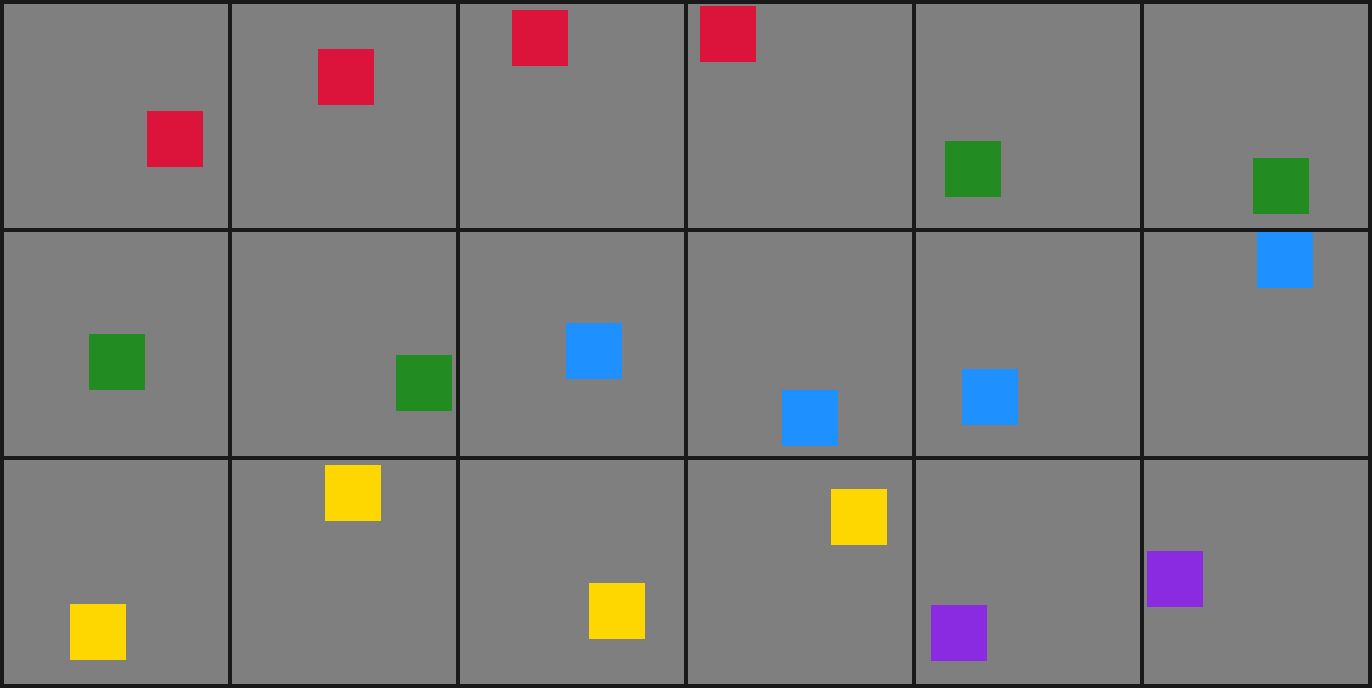

In [4]:
images, metadata = generate_square_stimuli(
    n_per_color=N_PER_COLOR,
    image_size=IMAGE_SIZE,
    square_size=SQUARE_SIZE,
    fixed_position=FIXED_POSITION,
    seed=SEED,
)

preview = build_preview_grid(images[: min(18, len(images))], ncols=6)
preview_path = OUTPUT_DIR / f"preview_pipeline_{MODEL_NAME}.png"
preview.save(preview_path)
print("n_images:", len(images))
print("preview:", preview_path)
preview


In [5]:
wrapper = None

if LOAD_STORED_CACHE:
    payload = load_feature_cache(STORED_CACHE_NPZ)
    all_features = extract_feature_bundle(payload)
    prep_state = {
        key: value
        for key, value in payload.items()
        if key.startswith("mean_") or key.startswith("std_")
    }
    prep = LayerwisePreprocessor.from_state_dict(prep_state) if prep_state else None
else:
    wrapper = VisionEmbeddingWrapper(
        model_name=MODEL_NAME,
        pretrained=USE_PRETRAINED,
        device=DEVICE,
        pooling="auto",
    )
    raw_features = wrapper.extract(images, batch_size=BATCH_SIZE)
    if PREPROCESS_MODE == "zscore_l2":
        prep = LayerwisePreprocessor(use_zscore=True, l2_normalize=True)
    elif PREPROCESS_MODE == "l2_only":
        prep = LayerwisePreprocessor(use_zscore=False, l2_normalize=True)
    elif PREPROCESS_MODE == "zscore_only":
        prep = LayerwisePreprocessor(use_zscore=True, l2_normalize=False)
    elif PREPROCESS_MODE == "raw":
        prep = LayerwisePreprocessor(use_zscore=False, l2_normalize=False)
    else:
        raise ValueError(f"Unknown PREPROCESS_MODE: {PREPROCESS_MODE}")
    all_features = prep.fit_transform(raw_features)

{layer: feats.shape for layer, feats in all_features.items()}


{'layer_0': (24, 768), 'layer_6': (24, 768), 'layer_11': (24, 768)}

In [6]:
stored_indices, novel_probe_indices = build_balanced_splits_by_color(
    metadata,
    n_stored_per_color=N_STORED_PER_COLOR,
)

ident_task = build_identification_task(
    metadata,
    stored_indices=stored_indices,
    probe_indices=stored_indices,
)
gen_task = build_generalization_task_synthetic(
    metadata,
    stored_indices=stored_indices,
    probe_indices=novel_probe_indices,
    color_weight=COLOR_WEIGHT,
    position_weight=POSITION_WEIGHT,
)

stored_feature_bundle = subset_feature_bundle(all_features, ident_task.stored_indices)
gen_probe_feature_bundle = subset_feature_bundle(all_features, gen_task.probe_indices)

if prep is None:
    raise RuntimeError(
        "Loaded cache is missing preprocessing statistics. Rebuild the cache with "
        "vision/run_synthetic_features.py or set LOAD_STORED_CACHE = False."
    )

if wrapper is None:
    wrapper = VisionEmbeddingWrapper(
        model_name=MODEL_NAME,
        pretrained=USE_PRETRAINED,
        device=DEVICE,
        pooling="auto",
    )

ident_probe_images = [
    perturb_image(
        images[int(source_idx)],
        noise_std=IDENT_NOISE_STD,
        max_shift=IDENT_MAX_SHIFT,
        seed=SEED + 1000 + local_idx,
    )
    for local_idx, source_idx in enumerate(ident_task.probe_indices)
]
ident_probe_raw = wrapper.extract(ident_probe_images, batch_size=BATCH_SIZE)
ident_probe_feature_bundle = prep.transform(ident_probe_raw)

print("stored items:", len(ident_task.stored_indices))
print("generalization probes:", len(gen_task.probe_indices))
print("task mode:", TASK_MODE, "preprocess:", PREPROCESS_MODE, "metric:", METRIC)


stored items: 12
generalization probes: 12
task mode: mixed_color_position preprocess: zscore_l2 metric: cosine


In [7]:
ident_baseline = evaluate_layerwise_baseline(
    stored_feature_bundle,
    ident_probe_feature_bundle,
    ident_task.ground_truth_idx,
    metric=METRIC,
)
gen_baseline = evaluate_layerwise_baseline(
    stored_feature_bundle,
    gen_probe_feature_bundle,
    gen_task.ground_truth_idx,
    metric=METRIC,
)

ident_results = run_layerwise_identification(
    stored_feature_bundle,
    ident_probe_feature_bundle,
    ident_task.ground_truth_idx,
    n=DAM_ORDER,
    beta=DAM_BETA,
    alpha=DAM_ALPHA,
    lmbda=DAM_LAMBDA,
    steps_multiplier=STEPS_MULTIPLIER,
    retrieval_backend=RETRIEVAL_BACKEND,
    trace_every=TRACE_EVERY,
    metric=METRIC,
    normalize_retrieved=NORMALIZE_RETRIEVED_FOR_SCORING,
)

gen_results = run_layerwise_generalization(
    stored_feature_bundle,
    gen_probe_feature_bundle,
    gen_task.ground_truth_idx,
    n=DAM_ORDER,
    beta=DAM_BETA,
    alpha=DAM_ALPHA,
    lmbda=DAM_LAMBDA,
    steps_multiplier=STEPS_MULTIPLIER,
    retrieval_backend=RETRIEVAL_BACKEND,
    trace_every=TRACE_EVERY,
    metric=METRIC,
    normalize_retrieved=NORMALIZE_RETRIEVED_FOR_SCORING,
)

summary_rows = []
for layer in sorted(ident_results):
    summary_rows.append(
        {
            "layer": layer,
            "ident_baseline_accuracy": ident_baseline[layer]["accuracy"],
            "ident_dam_accuracy": ident_results[layer]["accuracy"],
            "ident_initial_sim": ident_results[layer]["avg_initial_sim"],
            "ident_final_sim": ident_results[layer]["avg_sim"],
            "ident_delta_sim": ident_results[layer]["avg_delta_sim"],
            "ident_retrieved_norm": ident_results[layer]["avg_retrieved_norm"],
            "ident_norm_ratio": ident_results[layer]["avg_retrieved_norm"] / max(ident_results[layer]["avg_target_norm"], 1e-12),
            "gen_baseline_accuracy": gen_baseline[layer]["accuracy"],
            "gen_dam_accuracy": gen_results[layer]["accuracy"],
            "gen_initial_sim": gen_results[layer]["avg_initial_sim"],
            "gen_final_sim": gen_results[layer]["avg_sim"],
            "gen_delta_sim": gen_results[layer]["avg_delta_sim"],
            "gen_retrieved_norm": gen_results[layer]["avg_retrieved_norm"],
            "gen_norm_ratio": gen_results[layer]["avg_retrieved_norm"] / max(gen_results[layer]["avg_target_norm"], 1e-12),
        }
    )

summary_rows


[{'layer': 'layer_0',
  'ident_baseline_accuracy': 66.66666666666666,
  'ident_dam_accuracy': 33.33333333333333,
  'ident_initial_sim': 0.14605178083359263,
  'ident_final_sim': 0.03431514039038264,
  'ident_delta_sim': -0.11173664044321001,
  'ident_retrieved_norm': 0.00031913497997698633,
  'ident_norm_ratio': 0.00031913498631762886,
  'gen_baseline_accuracy': 41.66666666666667,
  'gen_dam_accuracy': 16.666666666666664,
  'gen_initial_sim': 0.41881308977573406,
  'gen_final_sim': 0.0674045785960377,
  'gen_delta_sim': -0.35140851117969635,
  'gen_retrieved_norm': 0.00032916430657501755,
  'gen_norm_ratio': 0.0003291643131149249},
 {'layer': 'layer_11',
  'ident_baseline_accuracy': 8.333333333333332,
  'ident_dam_accuracy': 16.666666666666664,
  'ident_initial_sim': 0.12672032177097997,
  'ident_final_sim': 0.008414470474152945,
  'ident_delta_sim': -0.11830585129682698,
  'ident_retrieved_norm': 0.0003883120867416922,
  'ident_norm_ratio': 0.0003883120867416922,
  'gen_baseline_accur

In [8]:
def build_sweep_configs():
    configs = []
    for beta in SWEEP_BETAS:
        for alpha in SWEEP_ALPHAS:
            for lmbda in SWEEP_LAMBDAS:
                for steps_multiplier in SWEEP_STEPS_MULTIPLIERS:
                    for metric in SWEEP_METRICS:
                        for normalize_retrieved in SWEEP_NORMALIZE_RETRIEVED:
                            label = (
                                f"b{beta:g}_a{alpha:g}_l{lmbda:g}_"
                                f"s{steps_multiplier}_m{metric}_nr{int(normalize_retrieved)}"
                            )
                            configs.append(
                                {
                                    "label": label,
                                    "n": DAM_ORDER,
                                    "beta": beta,
                                    "alpha": alpha,
                                    "lmbda": lmbda,
                                    "steps_multiplier": steps_multiplier,
                                    "retrieval_backend": RETRIEVAL_BACKEND,
                                    "trace_every": TRACE_EVERY,
                                    "seed": SEED,
                                    "metric": metric,
                                    "normalize_retrieved": normalize_retrieved,
                                }
                            )
    return configs

sweep_configs = build_sweep_configs()

ident_sweep_rows = sweep_layerwise_dam_configs(
    stored_feature_bundle,
    ident_probe_feature_bundle,
    ident_task.ground_truth_idx,
    task_name="identification",
    configs=sweep_configs,
    collapse_threshold=COLLAPSE_THRESHOLD,
    overshoot_ratio=OVERSHOOT_RATIO,
)
gen_sweep_rows = sweep_layerwise_dam_configs(
    stored_feature_bundle,
    gen_probe_feature_bundle,
    gen_task.ground_truth_idx,
    task_name="generalization",
    configs=sweep_configs,
    collapse_threshold=COLLAPSE_THRESHOLD,
    overshoot_ratio=OVERSHOOT_RATIO,
)

top_ident_sweep_rows = ident_sweep_rows[:SWEEP_LIMIT]
top_gen_sweep_rows = gen_sweep_rows[:SWEEP_LIMIT]
top_ident_accuracy_rows = [row for row in ident_sweep_rows if row["retrieval_calibrated"] and row["baseline_delta_accuracy"] > 0][:SWEEP_LIMIT]
top_gen_accuracy_rows = [row for row in gen_sweep_rows if row["retrieval_calibrated"] and row["baseline_delta_accuracy"] > 0][:SWEEP_LIMIT]

print("ident sweep rows:", len(ident_sweep_rows))
print("gen sweep rows:", len(gen_sweep_rows))
top_ident_sweep_rows[:3], top_gen_sweep_rows[:3], top_ident_accuracy_rows[:3], top_gen_accuracy_rows[:3]


ident sweep rows: 864
gen sweep rows: 864


([{'task_name': 'identification',
   'config_index': 245,
   'config_label': 'b2.5_a0.1_l0_s20_mcosine_nr1',
   'layer': 'layer_0',
   'n': 4,
   'beta': 2.5,
   'alpha': 0.1,
   'lmbda': 0.0,
   'steps_multiplier': 20,
   'retrieval_backend': 'numba',
   'trace_every': 0,
   'seed': 0,
   'metric': 'cosine',
   'normalize_retrieved': True,
   'collapse_threshold': 0.05,
   'overshoot_ratio': 2.0,
   'retrieval_collapse': False,
   'retrieval_overshoot': False,
   'retrieval_calibrated': True,
   'baseline_accuracy': 66.66666666666666,
   'baseline_avg_sim': 0.14605178083359263,
   'dam_accuracy': 58.333333333333336,
   'baseline_delta_accuracy': -8.333333333333321,
   'avg_initial_sim': 0.14605178083359263,
   'avg_final_sim': 0.2366452216940488,
   'avg_delta_sim': 0.09059344086045618,
   'avg_retrieved_norm': 0.15461129802295945,
   'avg_probe_norm': 0.9999999751647314,
   'avg_target_norm': 0.999999980131785,
   'retrieved_norm_ratio': 0.15461130109481003,
   'winner_agreement': 83

In [9]:
summary_path = OUTPUT_DIR / f"vision_dam_summary_{MODEL_NAME}.json"
metadata_path = OUTPUT_DIR / f"vision_dam_metadata_{MODEL_NAME}.json"

summary_payload = {
    "model_name": MODEL_NAME,
    "seed": SEED,
    "task_mode": TASK_MODE,
    "preprocess_mode": PREPROCESS_MODE,
    "metric": METRIC,
    "collapse_threshold": COLLAPSE_THRESHOLD,
    "overshoot_ratio": OVERSHOOT_RATIO,
    "identification_baseline": ident_baseline,
    "generalization_baseline": gen_baseline,
    "identification": ident_results,
    "generalization": gen_results,
    "summary_rows": summary_rows,
    "identification_sweep": ident_sweep_rows,
    "generalization_sweep": gen_sweep_rows,
    "identification_sweep_top_calibrated": top_ident_sweep_rows,
    "generalization_sweep_top_calibrated": top_gen_sweep_rows,
    "identification_sweep_top_accuracy": top_ident_accuracy_rows,
    "generalization_sweep_top_accuracy": top_gen_accuracy_rows,
}
summary_path.write_text(json.dumps(summary_payload, indent=2), encoding="utf-8")
metadata_path.write_text(json.dumps(metadata_to_dicts(metadata), indent=2), encoding="utf-8")

print("saved:", summary_path)
print("saved:", metadata_path)


saved: results/vision/vision_dam_summary_vit_base_patch16_224.json
saved: results/vision/vision_dam_metadata_vit_base_patch16_224.json
